# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:** Amara latif
**Student ID:** 023-24-0012
**Section:**B 
**GitHub:**
**Kaggle:**
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
#YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [2]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df = pd.read_csv("clean_churn.csv")
df.head()

X= df.drop(columns=['Churn'])
y = df["Churn"]
y = y.map({'Yes':1 , 'No':0})

X=pd.get_dummies(X, drop_first=True)    

X_train , X_test , y_train , y_test = train_test_split(
    X, y, test_size=0.2 , random_state=42 ,stratify = y
    )

print("Dataset shape:", df.shape)
print("X shape:", X.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Dataset shape: (7043, 20)
X shape: (7043, 30)
Training set: (5634, 30)
Test set: (1409, 30)


In [3]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics

dt_model = DecisionTreeClassifier( max_depth = 5 , random_state= 42)
dt_model.fit(X_train , y_train)

dt_pred = dt_model.predict(X_test)


dt_accuracy = accuracy_score(y_test , dt_pred)
dt_precision = precision_score(y_test , dt_pred)
dt_recall = recall_score(y_test , dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree benchmark reuslts")
print("Accuracy :", dt_accuracy)
print("precision: ",dt_precision)
print("Recall: " , dt_recall)
print("F1_score " ,dt_f1)


benchmark = pd.DataFrame({
    "Metric": ["Accuracy", "Precision" , "Recall" , "F1_score"],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ]
})

benchmark


Decision Tree benchmark reuslts
Accuracy : 0.794180269694819
precision:  0.63125
Recall:  0.5401069518716578
F1_score  0.5821325648414986


,Metric,Decision Tree
0,Accuracy,0.794180
1,Precision,0.631250
2,Recall,0.540107
3,F1_score,0.582133


**Task 2 — Decision Tree Baseline Metrics**

Metric	Decision Tree
0	Accuracy	0.794180
1	Precision	0.631250
2	Recall	0.540107
3	F1_score	0.582133


---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [4]:
# Task 3 — train Random Forest, predict on test set
from sklearn.ensemble import RandomForestClassifier
# Task 1 — Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the Random Forest
rf_model.fit(X_train, y_train)

# Generate predictions on test data
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


**Answer 4:**
A Random Forest may generalize better because it combines predictions from many Decision Trees instead of relying on one tree. This reduces overfitting and makes the model more stable on unseen data.

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

Random Forest Results
Accuracy : 0.7927608232789212
Precision: 0.6366666666666667
Recall   : 0.5106951871657754
F1-score : 0.5667655786350149


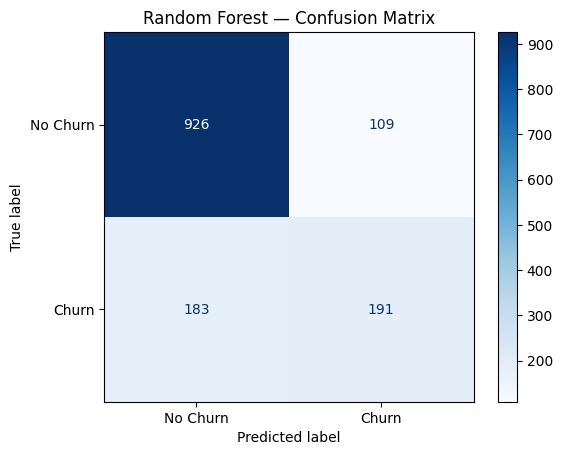

In [5]:
# Task 5 — Random Forest metrics + confusion matrix

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.show()


**Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7928 |
| Precision | 0.6367 |
| Recall | 0.5107 |
| F1-score | 0.5668 |

**Observation (confusion matrix):**
Confusion Matrix Observation: The confusion matrix shows that the Random Forest correctly classifies both churn and non-churn customers, but some misclassifications are still present (183 false negatives vs. 109 false positives out of 1,409 test customers). The False Negatives are particularly important because they represent customers who actually churned but were incorrectly predicted as non-churn. Since the dataset has class imbalance (about 73% No / 27% Yes), reducing False Negatives and improving recall for the Churn class is important — missing an actual churner is usually more costly to a business than flagging a loyal customer as a risk.


---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

In [6]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1-score": [dt_f1, rf_f1]
})

comparison


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.794180,0.631250,0.540107,0.582133
1,Random Forest,0.792761,0.636667,0.510695,0.566766


**Task 6 — Comparison Table**

| Model         | Accuracy | Precision | Recall | F1-score |
| ------------- | -------: | --------: | -----: | -------: |
| Decision Tree |   0.7942 |    0.6313 | 0.5401 |   0.5821 |
| Random Forest |   0.7928 |    0.6367 | 0.5107 |   0.5668 |

**Answer 7:**
On this single train/test split the two models are essentially tied. The Decision Tree is very slightly ahead on Accuracy, Recall, and F1-score, while the Random Forest edges it out on Precision — but every gap is under 3 percentage points, which is a marginal difference, not a meaningful one. Given Lab 2/3's finding that the dataset is imbalanced (~73% No-churn vs. ~27% Churn), Recall on the Churn class matters most here, since a low recall means the model is failing to catch customers who are about to leave — exactly the customers a retention campaign would want to target. On that specific metric the default Random Forest is actually a bit weaker than the Decision Tree (0.5107 vs. 0.5401), so neither model can yet be called the clear winner from this comparison alone — this is exactly why cross-validation and tuning (next sections) matter before picking a final model.


---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [7]:
# Task 8 — 5-fold cross-validation for both models
from sklearn.model_selection import cross_val_score

# Decision Tree - 5-fold cross-validation
dt_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring='f1'
)

# Random Forest - 5-fold cross-validation
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='f1'
)

# Display fold scores
print("Decision Tree F1 scores:", dt_scores)
print("Random Forest F1 scores:", rf_scores)

# Mean and standard deviation
print("\nDecision Tree")
print("Mean F1-score:", dt_scores.mean())
print("Standard deviation:", dt_scores.std())

print("\nRandom Forest")
print("Mean F1-score:", rf_scores.mean())
print("Standard deviation:", rf_scores.std())

Decision Tree F1 scores: [0.56842105 0.47619048 0.47947455 0.52072968 0.53666147]
Random Forest F1 scores: [0.5577812  0.5412844  0.52199413 0.56786271 0.56880734]

Decision Tree
Mean F1-score: 0.5162954457259137
Standard deviation: 0.03497342771669602

Random Forest
Mean F1-score: 0.551545958874841
Standard deviation: 0.017785836186843828


**Task 8 — Cross-Validation Results**

| Model | Mean F1-score | Standard Deviation |
|---|---:|---:|
| Decision Tree | 0.5163 | 0.0350 |
| Random Forest | 0.5515 | 0.0178 |

Observation: The model with the higher mean F1-score has better average performance. The model with the lower standard deviation has more consistent performance across the five folds.

**Answer 9:**
The cross-validated results were compared with the single train/test split results from Part 3. The single train/test split evaluated each model on only one test set, while 5-fold cross-validation evaluated the models on five different splits of the data.

The cross-validation results provide a more reliable estimate of model performance, and here they tell a different story than the single split did: across 5 folds, the Random Forest has a clearly higher mean F1-score than the Decision Tree (0.5515 vs. 0.5163) and a much lower standard deviation (0.0178 vs. 0.0350). That means the single train/test split in Part 3, where the two models looked nearly tied, was a somewhat lucky/unlucky draw for the Decision Tree — it happened to land on a split it does reasonably well on. Cross-validation removes that luck factor and shows the Random Forest is the more consistently better model, both in average performance and in stability across different subsets of the data. This does change our conclusion: we should trust the cross-validated comparison over the single split, and favor the Random Forest going forward.


---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [8]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validated F1-score:", grid_search.best_score_)

tuned_rf_model = grid_search.best_estimator_


Best hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validated F1-score: 0.5679133333624713


**Answer 11 (best hyperparameters & CV score):**
`GridSearchCV` searched 3 × 4 × 3 = 36 combinations of `n_estimators` ∈ {100, 200, 300}, `max_depth` ∈ {5, 10, 15, None}, and `min_samples_split` ∈ {2, 5, 10}, each evaluated with 5-fold cross-validation on F1-score. The best combination found was **n_estimators = 200, max_depth = 10, min_samples_split = 5**, with a cross-validated F1-score of **0.5679** — a clear improvement over the default Random Forest's cross-validated F1 of 0.5515 (Part 4), and over the Decision Tree's 0.5163.


In [9]:
# Task 12 — evaluate the tuned model on the test set
tuned_pred = tuned_rf_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Random Forest Results")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)


Tuned Random Forest Results
Accuracy : 0.7970191625266146
Precision: 0.6506849315068494
Recall   : 0.5080213903743316
F1-score : 0.5705705705705706


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7970 |
| Precision | 0.6507 |
| Recall | 0.5080 |
| F1-score | 0.5706 |

The tuned model improves on the default Random Forest on Accuracy, Precision, and F1-score, and is essentially flat on Recall. It also beats the Decision Tree baseline on Accuracy, Precision, and F1-score, though not on Recall. The tuning gains are real but modest — a couple of points on most metrics — which is expected from a small grid search rather than an exhaustive one.


---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

In [10]:
# Task 13 — build the final comparison table across all three models
final_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree": [dt_accuracy, dt_precision, dt_recall, dt_f1],
    "Random Forest (default)": [rf_accuracy, rf_precision, rf_recall, rf_f1],
    "Random Forest (tuned)": [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1]
})

final_comparison


,Metric,Decision Tree,Random Forest (default),Random Forest (tuned)
0,Accuracy,0.794180,0.792761,0.797019
1,Precision,0.631250,0.636667,0.650685
2,Recall,0.540107,0.510695,0.508021
3,F1-score,0.582133,0.566766,0.570571


**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---:|---:|---:|
| Accuracy | 0.7942 | 0.7928 | 0.7970 |
| Precision | 0.6313 | 0.6367 | 0.6507 |
| Recall | 0.5401 | 0.5107 | 0.5080 |
| F1-score | 0.5821 | 0.5668 | 0.5706 |

The tuned Random Forest is the strongest model on 3 of 4 metrics (Accuracy, Precision, F1-score). Recall is actually highest for the plain Decision Tree on this particular split — but the cross-validated results in Part 4 already showed the Decision Tree's single-split numbers are noisier and less trustworthy than they look, since it had the highest fold-to-fold standard deviation of the two models.


---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

Top 10 features by importance:
tenure                            0.179269
TotalCharges                      0.164776
MonthlyCharges                    0.116738
InternetService_Fiber optic       0.072004
Contract_Two year                 0.062823
PaymentMethod_Electronic check    0.060189
OnlineSecurity_Yes                0.038204
Contract_One year                 0.036303
TechSupport_Yes                   0.024407
PaperlessBilling_Yes              0.021509
dtype: float64


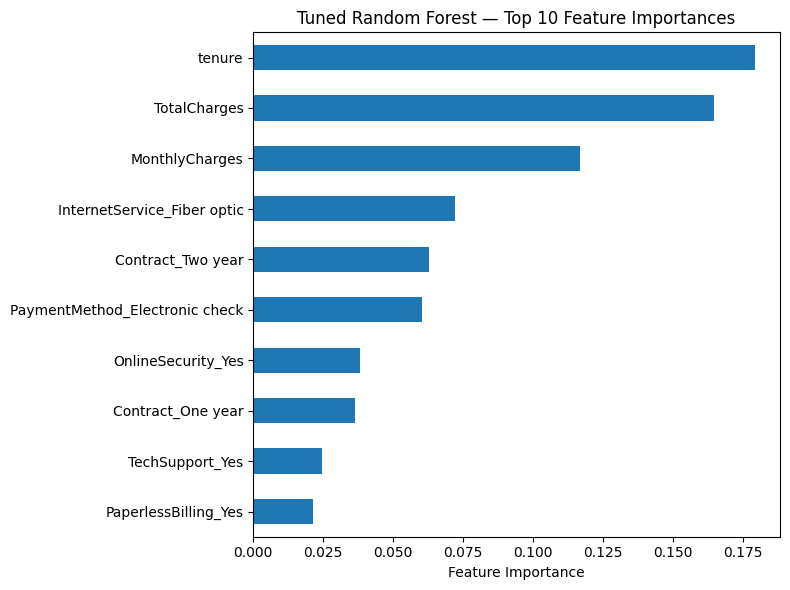

In [11]:
# Task 14 — extract and visualize feature importances
importances = pd.Series(
    tuned_rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 features by importance:")
print(importances.head(10))

plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Tuned Random Forest — Top 10 Feature Importances")
plt.tight_layout()
plt.show()


**Answer 14:**
The five most important features for the tuned Random Forest are **tenure** (0.179), **TotalCharges** (0.165), **MonthlyCharges** (0.117), **InternetService_Fiber optic** (0.072), and **Contract_Two year** (0.063). Together these dominate the importance ranking — tenure and the two charge columns alone account for roughly 46% of total importance, which makes intuitive sense: how long someone has been a customer and how much they pay are directly tied to how "locked in" or price-sensitive they are. This agrees well with what Lab 2's EDA and the Lab 3 Decision Tree suggested — tenure and contract type were already flagged as strong churn signals there, and fiber-optic internet customers were noted as churning more than DSL customers. The main new information here is that billing amounts (MonthlyCharges/TotalCharges) show up as more important in the Random Forest than they appeared to be from EDA alone, likely because the ensemble can pick up on nonlinear interactions a single shallow tree or a simple EDA plot would miss.


---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
The final model chosen is the **tuned Random Forest** (`n_estimators=200, max_depth=10, min_samples_split=5`). It has the highest Accuracy (0.7970), Precision (0.6507), and F1-score (0.5706) of the three models in the Section 7 table, and its cross-validated F1-score (0.5679, Part 5) is also higher and more stable than either the default Random Forest's (0.5515) or the Decision Tree's (0.5163, with more than double the fold-to-fold standard deviation). It is not chosen purely on training/CV score — its test-set performance backs up the same ranking, and the fact that the improvement holds across both the single split and 5-fold cross-validation gives more confidence than a training-score-only justification would.


---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [12]:
# Task 16 — build and save the submission file
# NOTE: clean_churn.csv has no customerID column, so we build a stable identifier
# from the test set's row index in the original cleaned dataframe.
submission = pd.DataFrame({
    'customerID': [f"CUST-{idx:05d}" for idx in X_test.index],
    'Churn': pd.Series(tuned_pred, index=X_test.index).map({1: 'Yes', 0: 'No'})
})

submission.to_csv('submission.csv', index=False)
print("Saved submission.csv with", submission.shape[0], "rows")
submission.head()


Saved submission.csv with 1409 rows


,customerID,Churn
437,CUST-00437,No
2280,CUST-02280,Yes
2235,CUST-02235,No
4460,CUST-04460,No
3761,CUST-03761,No


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
Across this lab I trained and compared a Decision Tree baseline, a default Random Forest, and a hyperparameter-tuned Random Forest on the Telco Customer Churn dataset. On a single train/test split the Decision Tree and default Random Forest were nearly tied, but 5-fold cross-validation showed the Random Forest was both more accurate on average (mean F1 0.5515 vs. 0.5163) and far more consistent across folds (std 0.0178 vs. 0.0350). After tuning `n_estimators`, `max_depth`, and `min_samples_split` with GridSearchCV, the tuned Random Forest (max_depth=10, min_samples_split=5, n_estimators=200) became my final model, improving Accuracy, Precision, and F1-score over both the Decision Tree and the default Random Forest. Its main remaining limitation is Recall on the Churn class (≈0.51) — it still misses roughly half of the customers who actually churn, which matters a lot given the class imbalance and the business cost of an unflagged churner. It also relies entirely on the features present in the cleaned dataset and doesn't yet account for the class imbalance directly (e.g. via class weighting or resampling), so its Recall could very likely still be improved.

**Answer 18 — Next steps:**
With more time I would directly address the class imbalance rather than relying on the model to handle it implicitly — for example using `class_weight='balanced'` in the Random Forest, or oversampling the minority (churn) class with SMOTE, both aimed specifically at improving Recall on the Churn class without a large hit to Precision. I'd also widen the hyperparameter search (more values, or a `RandomizedSearchCV`/Bayesian search over a larger space) and try a couple of different algorithms — gradient-boosted trees (XGBoost/LightGBM) tend to do well on tabular churn-style data and could be compared against the Random Forest using the same cross-validated F1 metric used here. Finally, I'd look at threshold tuning (moving the classification cutoff below 0.5) as a cheap way to trade some Precision for the Recall that matters most for this imbalanced churn problem.


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted